In [ ]:
# SVM kya hai?

# SVM ek supervised machine learning algorithm hai, mainly classification ke liye.

In [1]:
# Lekin SVM sirf koi bhi separating line nahi choose karta.

# It tries to choose the line with the maximum margin.

In [2]:
# SVM chahta hai:

# Boundary aur nearest points ke beech ka gap maximum ho.

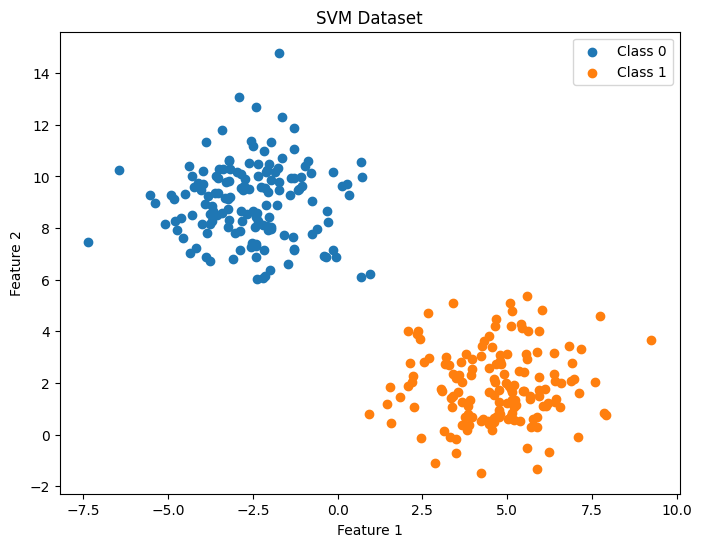

In [3]:
# code
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

# Create dataset
X, y = make_blobs(
    n_samples=300,
    centers=2,
    cluster_std=1.5,
    random_state=42
)

# Visualize
plt.figure(figsize=(8, 6))

plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    label="Class 0"
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Class 1"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("SVM Dataset")
plt.legend()
plt.show()

In [4]:
# SVM
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SVM
model = SVC(kernel="linear")

model.fit(X_train_scaled, y_train)

# Prediction
y_pred = model.predict(X_test_scaled)

print("Predictions:", y_pred[:20])
print("Actual:     ", y_test[:20])

print("Accuracy:", accuracy_score(y_test, y_pred))

Predictions: [0 0 0 0 0 0 1 0 1 0 1 1 0 1 1 1 1 0 1 1]
Actual:      [0 0 0 0 0 0 1 0 1 0 1 1 0 1 1 1 1 0 1 1]
Accuracy: 1.0


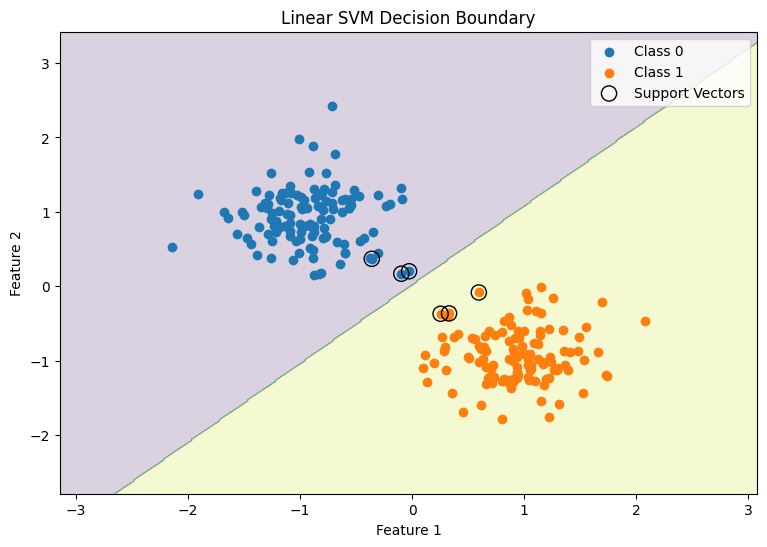

In [5]:
# now lets visualize the decision boudary
# Create grid
x_min = X_train_scaled[:, 0].min() - 1
x_max = X_train_scaled[:, 0].max() + 1

y_min = X_train_scaled[:, 1].min() - 1
y_max = X_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

grid = np.c_[xx.ravel(), yy.ravel()]

predictions = model.predict(grid)
predictions = predictions.reshape(xx.shape)

plt.figure(figsize=(9, 6))

plt.contourf(
    xx,
    yy,
    predictions,
    alpha=0.2
)

plt.scatter(
    X_train_scaled[y_train == 0, 0],
    X_train_scaled[y_train == 0, 1],
    label="Class 0"
)

plt.scatter(
    X_train_scaled[y_train == 1, 0],
    X_train_scaled[y_train == 1, 1],
    label="Class 1"
)

# Highlight support vectors
plt.scatter(
    model.support_vectors_[:, 0],
    model.support_vectors_[:, 1],
    s=120,
    facecolors="none",
    edgecolors="black",
    label="Support Vectors"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Linear SVM Decision Boundary")
plt.legend()
plt.show()

In [6]:
# C kya hai?

# SVM ka ek important hyperparameter hai:

# SVC(C=1)

# C basically control karta hai:

# Model mistakes ko kitna tolerate kare?

# Small C

# Model thodi mistakes tolerate karega.

# Boundary relatively wider margin rakhne ki koshish karegi.

# Large C

# Model training points ko zyada correctly classify karne ki koshish karega.

# Margin smaller ho sakta hai.

# Simple mental model:

# Small C
# → more tolerance
# → wider margin
# → simpler boundary
# → potentially underfitting

# Large C
# → less tolerance
# → stricter classification
# → potentially more complex
# → potentially overfitting

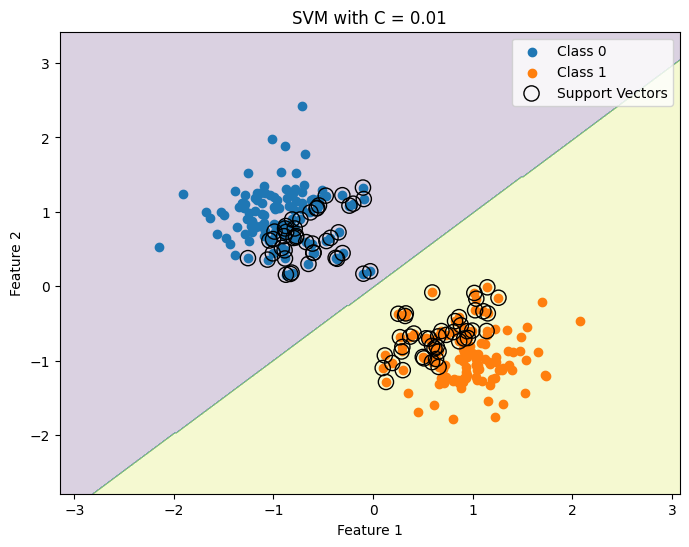

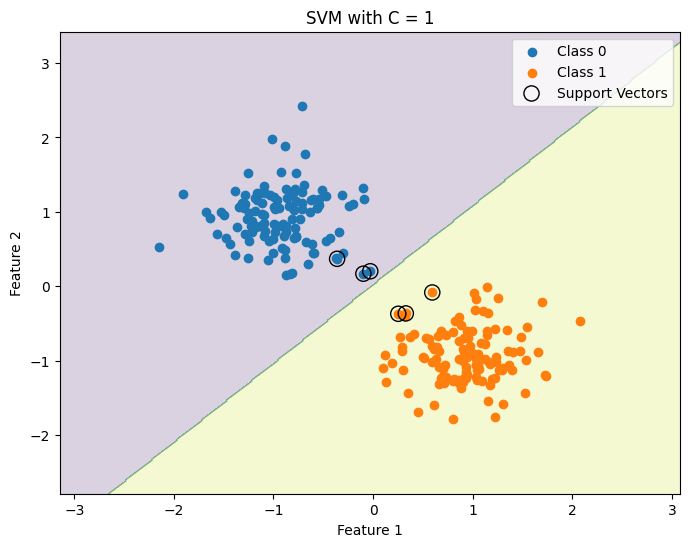

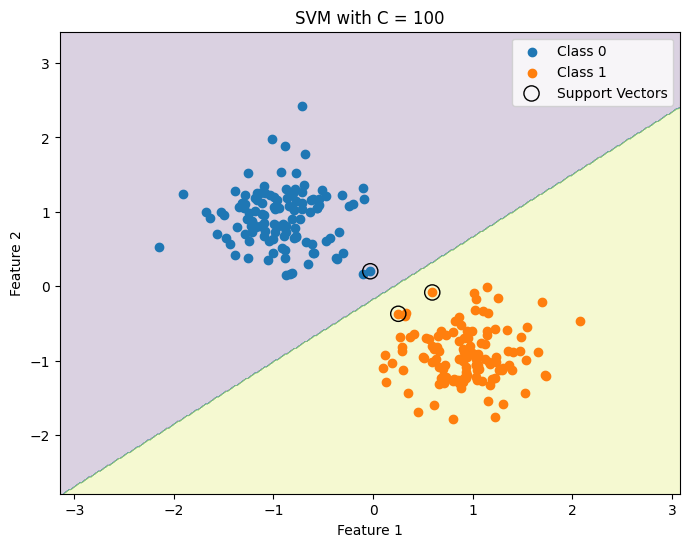

In [7]:
# for visualizing the impact of the c values
for C_value in [0.01, 1, 100]:

    svm = SVC(kernel="linear", C=C_value)
    svm.fit(X_train_scaled, y_train)

    plt.figure(figsize=(8, 6))

    svm_pred = svm.predict(grid).reshape(xx.shape)

    plt.contourf(
        xx,
        yy,
        svm_pred,
        alpha=0.2
    )

    plt.scatter(
        X_train_scaled[y_train == 0, 0],
        X_train_scaled[y_train == 0, 1],
        label="Class 0"
    )

    plt.scatter(
        X_train_scaled[y_train == 1, 0],
        X_train_scaled[y_train == 1, 1],
        label="Class 1"
    )

    plt.scatter(
        svm.support_vectors_[:, 0],
        svm.support_vectors_[:, 1],
        s=120,
        facecolors="none",
        edgecolors="black",
        label="Support Vectors"
    )

    plt.title(f"SVM with C = {C_value}")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.show()

In [8]:
# kernal
# lower dimension ko higher dimension data me convert karo and then
# tm use separate kar sakte ho


In [9]:
# # RBF Kernel
# Most commonly used nonlinear kernel:

# SVC(kernel="rbf")

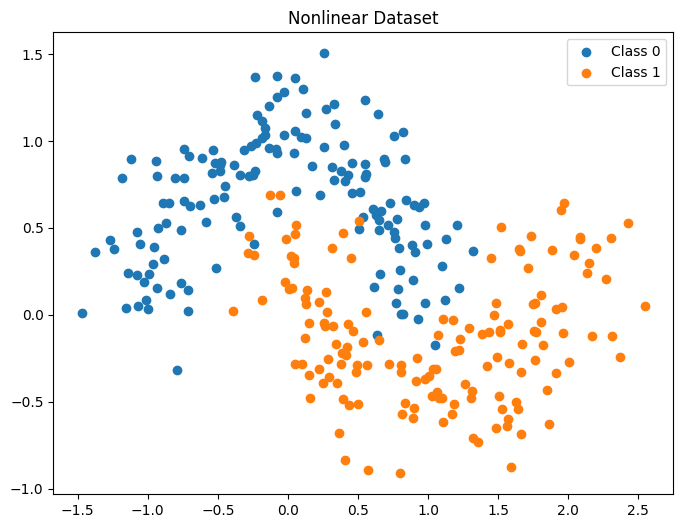

In [10]:
from sklearn.datasets import make_moons

X, y = make_moons(
    n_samples=300,
    noise=0.2,
    random_state=42
)

plt.figure(figsize=(8, 6))

plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    label="Class 0"
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Class 1"
)

plt.title("Nonlinear Dataset")
plt.legend()
plt.show()

In [11]:
# straight light svm
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

linear_svm = SVC(kernel="linear")
linear_svm.fit(X_train_scaled, y_train)

print(
    "Linear SVM accuracy:",
    linear_svm.score(X_test_scaled, y_test)
)

Linear SVM accuracy: 0.7833333333333333


In [12]:
# now RBF
rbf_svm = SVC(
    kernel="rbf",
    C=1,
    gamma="scale"
)

rbf_svm.fit(X_train_scaled, y_train)

print(
    "RBF SVM accuracy:",
    rbf_svm.score(X_test_scaled, y_test)
)

RBF SVM accuracy: 0.8666666666666667


In [13]:
# the accuracy is greater than the linear kernel svm

In [14]:
# Gamma
# Gamma decide karta hai ke ek
# training point ka influence kitni door tak spread hoga.

In [15]:
# Low gamma
# → broad influence
# → smoother boundary

# High gamma
# → local influence
# → more complex boundary
# → overfitting ka risk

In [16]:
# SVM kab use karna hai?

# Good cases:

# Classification problems
# Small/medium datasets
# High-dimensional feature spaces
# Text classification
# Clear class separation
# Nonlinear boundaries with RBF kernel

# Avoid / less ideal when:

# Dataset bohot huge ho
# Training speed important ho
# Millions of samples hon
# Features badly scaled hon
# You need extremely simple interpretability

# SVM especially scaling-sensitive hai.

# So generally:

# Data
#  ↓
# Train/Test Split
#  ↓
# StandardScaler
#  ↓
# SVM
#  ↓
# Prediction

In [17]:
# SVM is a supervised machine learning algorithm that finds an
# optimal decision boundary by maximizing the margin between classes.
# The closest training points to the boundary are called support vectors.
# With kernels such as RBF, SVM can also handle nonlinear classification problems.